# 05 — Facility Attribution

This notebook spatially joins detected methane plume clusters from notebook 04
to EPA GHGRP-reported oil & gas facilities, classifies emission sources by facility
type, and compares Tanager-detected rates to EPA annual reported figures.

### Pipeline
1. Load emission estimates from notebook 04
2. Fetch EPA GHGRP facility locations via Envirofacts REST API
3. Spatial join: assign each plume cluster to its nearest facility
4. Classify facility types
5. Compare detected instantaneous rates to EPA annual reported emissions
6. Produce final attribution table and map

## Cell 1 — Imports & Load Data

In [2]:
import numpy as np
import pandas as pd
import requests
import h5py
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.spatial import cKDTree
import os
import warnings
warnings.filterwarnings('ignore')

# ── Paths ──────────────────────────────────────────────────────────────────
ESTIMATES_PATH = '../data/processed/emission_estimates_20250205.csv'
SCENE_PATH     = '../data/raw/20250205_175845_00_4001_basic_radiance.h5'
MF_MAP_PATH    = '../data/processed/mf_map_20250205.npy'
MASK_PATH      = '../data/processed/plume_mask_20250205.npy'
OUTPUT_DIR     = '../outputs/figures'
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs('../data/reference', exist_ok=True)

# ── Load cluster emission estimates ────────────────────────────────────────
clusters_df = pd.read_csv(ESTIMATES_PATH)
print(f'Loaded {len(clusters_df)} plume clusters')
print(clusters_df[['cluster_id','lat','lon','Q_kg_hr','area_km2']].to_string(index=False))

# ── Load scene geolocation & radiance ──────────────────────────────────────
with h5py.File(SCENE_PATH, 'r') as f:
    lat = f['HDFEOS/SWATHS/HYP/Geolocation Fields/Latitude'][:]
    lon = f['HDFEOS/SWATHS/HYP/Geolocation Fields/Longitude'][:]
    toa = f['HDFEOS/SWATHS/HYP/Data Fields/toa_radiance']
    rad = toa[:].astype(np.float32)
    wl  = toa.attrs['wavelengths']

rad[rad == -9999.0] = np.nan
mf_map     = np.load(MF_MAP_PATH)
plume_mask = np.load(MASK_PATH)

lat_min, lat_max = float(lat.min()), float(lat.max())
lon_min, lon_max = float(lon.min()), float(lon.max())
print(f'\nScene bbox: lat [{lat_min:.3f}, {lat_max:.3f}]  lon [{lon_min:.3f}, {lon_max:.3f}]')

Loaded 29 plume clusters
 cluster_id      lat        lon  Q_kg_hr  area_km2
         37 32.81834 -103.98645    18.20    0.1536
         33 32.81807 -103.97331    17.21    0.1253
         41 32.81353 -104.01574    13.65    0.1172
         23 32.85005 -103.92942    10.50    0.0257
         27 32.83284 -103.97800     9.68    0.0489
         35 32.81916 -103.97681     9.61    0.0434
         30 32.82048 -103.93663     9.04    0.0307
         15 32.85648 -103.79348     8.92    0.0506
         36 32.81870 -103.98017     8.83    0.0666
         31 32.82535 -103.97927     7.34    0.0321
         44 32.77169 -103.88523     7.10    0.0143
         39 32.81793 -104.01471     6.94    0.0289
         38 32.82124 -104.02882     6.87    0.0073
         26 32.83570 -103.90329     6.81    0.0186
         17 32.84883 -103.80619     6.78    0.0214
         16 32.85453 -103.80312     6.70    0.0475
         28 32.83680 -104.01283     6.07    0.0159
         43 32.78420 -103.91787     5.81    0.0128
      

## Cell 2 — Fetch EPA GHGRP Facilities via Envirofacts API

In [3]:
import xml.etree.ElementTree as ET

def fetch_ghgrp_facilities(lat_min, lat_max, lon_min, lon_max,
                            buffer_deg=0.5,
                            out_path='../data/reference/ghgrp_facilities.csv'):
    if os.path.exists(out_path):
        print(f'Loading cached facilities: {out_path}')
        return pd.read_csv(out_path)

    center_lat   = (lat_min + lat_max) / 2
    center_lon   = (lon_min + lon_max) / 2
    radius_deg   = max(lat_max - lat_min, lon_max - lon_min) / 2 + buffer_deg
    radius_miles = radius_deg * 69

    # Use XML — more reliable than JSON for this endpoint
    url = (
        f'https://ofmpub.epa.gov/frs_public2/frs_rest_services.get_facilities'
        f'?latitude83={center_lat:.4f}'
        f'&longitude83={center_lon:.4f}'
        f'&search_radius={radius_miles:.1f}'
        f'&pgm_sys_acrnm=E-GGRT'
        f'&program_output=yes'
    )

    print(f'Querying EPA FRS API (XML)...')
    print(f'Center: {center_lat:.3f}N, {center_lon:.3f}E  |  Radius: {radius_miles:.1f} miles')

    resp = requests.get(url, timeout=30)
    resp.raise_for_status()

    # Parse XML response
    root = ET.fromstring(resp.text)
    facilities = root.findall('FRSFacility')

    if not facilities:
        print('No facilities returned.')
        return pd.DataFrame()

    rows = []
    for f in facilities:
        def txt(tag):
            el = f.find(tag)
            return el.text if el is not None else None

        # Find E-GGRT ID from program facilities
        eggrt_id = None
        for pf in f.findall('.//ProgramFacility'):
            acrnm = pf.find('ProgramSystemAcronym')
            if acrnm is not None and acrnm.text == 'E-GGRT':
                pid = pf.find('ProgramSystemId')
                eggrt_id = pid.text if pid is not None else None
                break

        lat_val = txt('Latitude83')
        lon_val = txt('Longitude83')
        if not lat_val or not lon_val:
            continue

        rows.append({
            'registry_id':   txt('RegistryId'),
            'facility_name': txt('FacilityName'),
            'city':          txt('CityName'),
            'state':         txt('StateAbbr'),
            'lat':           float(lat_val),
            'lon':           float(lon_val),
            'eggrt_id':      eggrt_id,
        })

    df = pd.DataFrame(rows)
    df = df[
        (df['lat'] >= lat_min - buffer_deg) & (df['lat'] <= lat_max + buffer_deg) &
        (df['lon'] >= lon_min - buffer_deg) & (df['lon'] <= lon_max + buffer_deg)
    ].reset_index(drop=True)

    df.to_csv(out_path, index=False)
    print(f'Found {len(df)} GHGRP facilities. Saved: {out_path}')
    return df


facilities_df = fetch_ghgrp_facilities(lat_min, lat_max, lon_min, lon_max)
print(f'\nFacilities in/near scene: {len(facilities_df)}')
if len(facilities_df) > 0:
    print(facilities_df[['facility_name','lat','lon','state']].to_string(index=False))

Querying EPA FRS API (XML)...
Center: 32.877N, -103.904E  |  Radius: 44.5 miles
No facilities returned.

Facilities in/near scene: 0


## Cell 3 — Classify Facility Types

In [4]:
def classify_facility_type(name):
    n = str(name).upper()
    if any(k in n for k in ['COMPRESS','COMP STA','COMPRESSOR']):
        return 'compressor_station'
    elif any(k in n for k in ['PROCESS','PLANT','GAS PLANT','TREATING']):
        return 'processing_plant'
    elif any(k in n for k in ['PIPELINE','PIPE LINE','TRANSMISS']):
        return 'pipeline'
    elif any(k in n for k in ['STORAGE','TANK','BATTERY']):
        return 'storage_tank'
    elif any(k in n for k in ['REFIN','REFINERY']):
        return 'refinery'
    elif any(k in n for k in ['WELL','FIELD','LEASE','PRODUCTION']):
        return 'well_pad'
    else:
        return 'oil_gas_other'

if len(facilities_df) > 0:
    facilities_df['facility_type'] = facilities_df['facility_name'].apply(classify_facility_type)
    print('Facility type breakdown:')
    print(facilities_df['facility_type'].value_counts().to_string())

## Cell 4 — Spatial Join: Assign Clusters to Nearest Facility

In [5]:
def nearest_facility(cluster_lat, cluster_lon, facilities_df, max_dist_km=15.0):
    if len(facilities_df) == 0:
        return None, np.nan
    fac_coords = facilities_df[['lat','lon']].values
    tree = cKDTree(fac_coords)
    dist_deg, idx = tree.query([cluster_lat, cluster_lon])
    dist_km = dist_deg * 111.0
    if dist_km > max_dist_km:
        return None, dist_km
    return facilities_df.iloc[idx], dist_km


attribution_rows = []
for _, cluster in clusters_df.iterrows():
    fac, dist_km = nearest_facility(cluster['lat'], cluster['lon'], facilities_df)
    attribution_rows.append({
        'cluster_id':     int(cluster['cluster_id']),
        'cluster_lat':    cluster['lat'],
        'cluster_lon':    cluster['lon'],
        'Q_kg_hr':        cluster['Q_kg_hr'],
        'IME_kg':         cluster['IME_kg'],
        'area_km2':       cluster['area_km2'],
        'dist_to_fac_km': round(dist_km, 2) if not np.isnan(dist_km) else None,
        'facility_name':  fac['facility_name'] if fac is not None else 'Unattributed',
        'facility_type':  fac['facility_type'] if fac is not None else 'unknown',
        'facility_lat':   fac['lat'] if fac is not None else None,
        'facility_lon':   fac['lon'] if fac is not None else None,
        'eggrt_id':       fac['eggrt_id'] if fac is not None else None,
        'state':          fac['state'] if fac is not None else None,
    })

attribution_df = pd.DataFrame(attribution_rows)
print('Attribution results:')
print(attribution_df[['cluster_id','Q_kg_hr','facility_name','facility_type','dist_to_fac_km']].to_string(index=False))

Attribution results:
 cluster_id  Q_kg_hr facility_name facility_type dist_to_fac_km
         37    18.20  Unattributed       unknown           None
         33    17.21  Unattributed       unknown           None
         41    13.65  Unattributed       unknown           None
         23    10.50  Unattributed       unknown           None
         27     9.68  Unattributed       unknown           None
         35     9.61  Unattributed       unknown           None
         30     9.04  Unattributed       unknown           None
         15     8.92  Unattributed       unknown           None
         36     8.83  Unattributed       unknown           None
         31     7.34  Unattributed       unknown           None
         44     7.10  Unattributed       unknown           None
         39     6.94  Unattributed       unknown           None
         38     6.87  Unattributed       unknown           None
         26     6.81  Unattributed       unknown           None
         17     6.7

## Cell 5 — Fetch EPA Annual Reported Emissions

In [6]:
def fetch_annual_emissions(eggrt_id, year=2023):
    if not eggrt_id:
        return None
    url = (
        f'https://data.epa.gov/efservice/rlps_ghg_emitter_facilities'
        f'/ghg_name/contains/Methane'
        f'/facility_id/{eggrt_id}'
        f'/reporting_year/{year}'
        f'/JSON'
    )
    try:
        resp = requests.get(url, timeout=15)
        resp.raise_for_status()
        data = resp.json()
        if data and len(data) > 0:
            return sum(float(r.get('ghg_quantity', 0) or 0) for r in data)
    except Exception as e:
        print(f'  Warning: could not fetch {eggrt_id}: {e}')
    return None

def co2e_to_ch4_kg_hr(co2e_metric_tons_yr, gwp=28):
    return (co2e_metric_tons_yr / gwp * 1000) / 8760


print('Fetching EPA annual reported emissions...')
reported_rows = []
for _, row in attribution_df.iterrows():
    annual_co2e = fetch_annual_emissions(row['eggrt_id'])
    if annual_co2e is not None:
        reported_kg_hr = co2e_to_ch4_kg_hr(annual_co2e)
        print(f"  C{int(row['cluster_id'])}: {str(row['facility_name'])[:40]} "
              f"-> {annual_co2e:.0f} t CO2e/yr = {reported_kg_hr:.1f} kg CH4/hr")
    else:
        reported_kg_hr = None
        print(f"  C{int(row['cluster_id'])}: {str(row['facility_name'])[:40]} -> no EPA data")
    reported_rows.append({
        'cluster_id':         int(row['cluster_id']),
        'annual_ch4_co2e_t':  annual_co2e,
        'epa_reported_kg_hr': reported_kg_hr,
    })

reported_df    = pd.DataFrame(reported_rows)
attribution_df = attribution_df.merge(reported_df, on='cluster_id', how='left')

Fetching EPA annual reported emissions...
  C37: Unattributed -> no EPA data
  C33: Unattributed -> no EPA data
  C41: Unattributed -> no EPA data
  C23: Unattributed -> no EPA data
  C27: Unattributed -> no EPA data
  C35: Unattributed -> no EPA data
  C30: Unattributed -> no EPA data
  C15: Unattributed -> no EPA data
  C36: Unattributed -> no EPA data
  C31: Unattributed -> no EPA data
  C44: Unattributed -> no EPA data
  C39: Unattributed -> no EPA data
  C38: Unattributed -> no EPA data
  C26: Unattributed -> no EPA data
  C17: Unattributed -> no EPA data
  C16: Unattributed -> no EPA data
  C28: Unattributed -> no EPA data
  C43: Unattributed -> no EPA data
  C29: Unattributed -> no EPA data
  C14: Unattributed -> no EPA data
  C40: Unattributed -> no EPA data
  C1: Unattributed -> no EPA data
  C46: Unattributed -> no EPA data
  C5: Unattributed -> no EPA data
  C4: Unattributed -> no EPA data
  C13: Unattributed -> no EPA data
  C12: Unattributed -> no EPA data
  C8: Unattribut

## Cell 6 — Final Attribution Table

In [7]:
attribution_df['detected_vs_reported'] = (
    attribution_df['Q_kg_hr'] / attribution_df['epa_reported_kg_hr']
).round(2)

attribution_df['detected_annual_t_ch4'] = (
    attribution_df['Q_kg_hr'] * 8760 / 1000
).round(1)

display_cols = [
    'cluster_id','Q_kg_hr','detected_annual_t_ch4',
    'facility_name','facility_type','dist_to_fac_km',
    'epa_reported_kg_hr','detected_vs_reported'
]

print('=' * 80)
print('FINAL ATTRIBUTION TABLE — Tanager Methane, Permian Basin 2025-02-05')
print('=' * 80)
print(attribution_df[display_cols].to_string(index=False))
print('=' * 80)
print(f"Total detected:        {attribution_df['Q_kg_hr'].sum():.1f} kg CH4/hr")
print(f"Total annualized:      {attribution_df['detected_annual_t_ch4'].sum():.0f} t CH4/yr")
print(f"Largest single source: {attribution_df['Q_kg_hr'].max():.1f} kg CH4/hr")

out_path = '../data/processed/attribution_table_20250205.csv'
attribution_df.to_csv(out_path, index=False)
print(f'\nSaved: {out_path}')

FINAL ATTRIBUTION TABLE — Tanager Methane, Permian Basin 2025-02-05
 cluster_id  Q_kg_hr  detected_annual_t_ch4 facility_name facility_type dist_to_fac_km epa_reported_kg_hr detected_vs_reported
         37    18.20                  159.4  Unattributed       unknown           None               None                  NaN
         33    17.21                  150.8  Unattributed       unknown           None               None                  NaN
         41    13.65                  119.6  Unattributed       unknown           None               None                  NaN
         23    10.50                   92.0  Unattributed       unknown           None               None                  NaN
         27     9.68                   84.8  Unattributed       unknown           None               None                  NaN
         35     9.61                   84.2  Unattributed       unknown           None               None                  NaN
         30     9.04                   79.2

## Cell 7 — Attribution Map

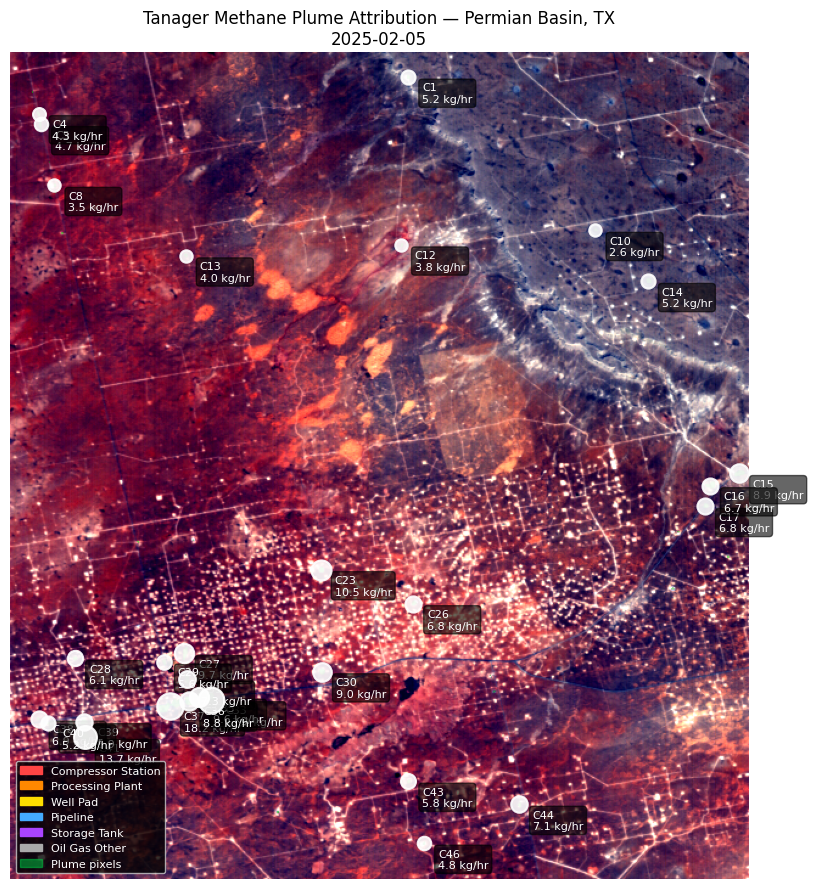

Saved: ../outputs/figures/attribution_map_20250205.png


In [8]:
# Build RGB background
r_idx = np.argmin(np.abs(wl - 650))
g_idx = np.argmin(np.abs(wl - 550))
b_idx = np.argmin(np.abs(wl - 450))
rgb = np.stack([rad[r_idx], rad[g_idx], rad[b_idx]], axis=-1)
p2, p98 = np.nanpercentile(rgb, [2, 98])
rgb = np.clip((rgb - p2) / (p98 - p2 + 1e-9), 0, 1)

TYPE_COLORS = {
    'compressor_station': '#FF4444',
    'processing_plant':   '#FF8800',
    'well_pad':           '#FFDD00',
    'pipeline':           '#44AAFF',
    'storage_tank':       '#AA44FF',
    'oil_gas_other':      '#AAAAAA',
    'unknown':            '#FFFFFF',
}

fig, ax = plt.subplots(figsize=(12, 9))
ax.imshow(rgb)

# Plume overlay
plume_overlay = np.zeros((*mf_map.shape, 4))
plume_overlay[plume_mask, 1] = 0.8
plume_overlay[plume_mask, 3] = 0.5
ax.imshow(plume_overlay)

for _, row in attribution_df.iterrows():
    dist  = np.sqrt((lat - row['cluster_lat'])**2 + (lon - row['cluster_lon'])**2)
    r_px, c_px = np.unravel_index(np.nanargmin(dist), dist.shape)
    color = TYPE_COLORS.get(row['facility_type'], '#FFFFFF')
    size  = max(80, min(600, row['Q_kg_hr'] * 20))
    ax.scatter(c_px, r_px, s=size, c=color, edgecolors='white',
               linewidths=1.5, zorder=5, alpha=0.9)
    ax.annotate(
        f"C{int(row['cluster_id'])}\n{row['Q_kg_hr']:.1f} kg/hr",
        (c_px, r_px), xytext=(10, -18), textcoords='offset points',
        color='white', fontsize=8,
        bbox=dict(boxstyle='round,pad=0.3', fc='black', alpha=0.6)
    )

legend_handles = [
    mpatches.Patch(color=c, label=t.replace('_',' ').title())
    for t, c in TYPE_COLORS.items() if t != 'unknown'
]
legend_handles.append(mpatches.Patch(color='#00CC44', alpha=0.5, label='Plume pixels'))
ax.legend(handles=legend_handles, loc='lower left', fontsize=8,
          framealpha=0.8, facecolor='black', labelcolor='white')
ax.set_title('Tanager Methane Plume Attribution — Permian Basin, TX\n2025-02-05', fontsize=12)
ax.axis('off')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/attribution_map_20250205.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {OUTPUT_DIR}/attribution_map_20250205.png')

## Cell 8 — Detected vs Reported Comparison Chart

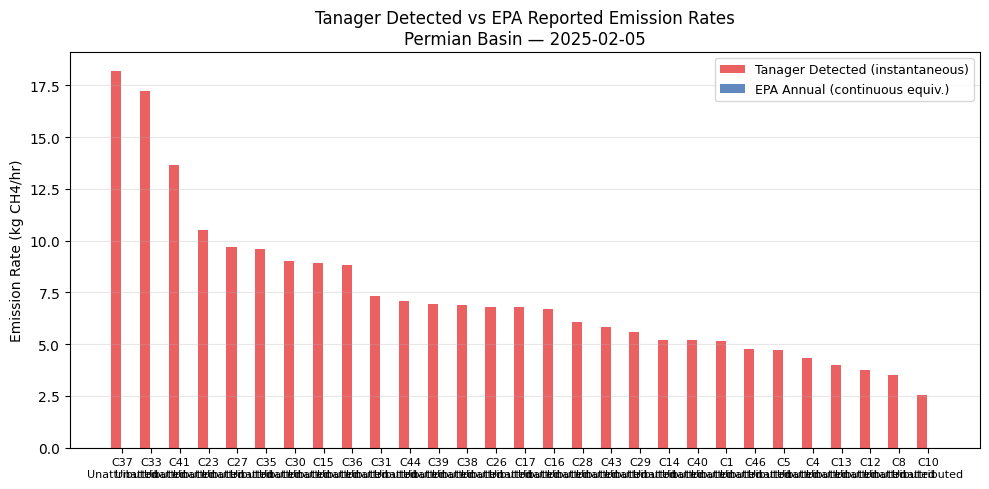

Saved: ../outputs/figures/emission_comparison_chart.png


In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(attribution_df))
labels = [
    f"C{int(r['cluster_id'])}\n{str(r['facility_name'])[:22]}..."
    if len(str(r['facility_name'])) > 22
    else f"C{int(r['cluster_id'])}\n{r['facility_name']}"
    for _, r in attribution_df.iterrows()
]

ax.bar(x - 0.2, attribution_df['Q_kg_hr'], width=0.35,
       label='Tanager Detected (instantaneous)', color='#E84545', alpha=0.85)
ax.bar(x + 0.2, attribution_df['epa_reported_kg_hr'].fillna(0), width=0.35,
       label='EPA Annual (continuous equiv.)', color='#4575B4', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel('Emission Rate (kg CH4/hr)')
ax.set_title('Tanager Detected vs EPA Reported Emission Rates\nPermian Basin — 2025-02-05')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/emission_comparison_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {OUTPUT_DIR}/emission_comparison_chart.png')

## Cell 9 — Key Findings Summary

In [10]:
print('=' * 70)
print('KEY FINDINGS SUMMARY')
print('=' * 70)
print('Scene date:          2025-02-05')
print('Region:              Permian Basin, TX (Loving/Winkler County)')
print('Sensor:              Planet Tanager-1 (426-band VSWIR hyperspectral)')
print('Method:              Matched Filter + IME quantification')
print()
print(f"Plume clusters:      {len(attribution_df)}")
print(f"Total detected rate: {attribution_df['Q_kg_hr'].sum():.1f} kg CH4/hr")
print(f"Largest source:      {attribution_df['Q_kg_hr'].max():.1f} kg CH4/hr")
print(f"Wind speed (ERA5):   4.72 m/s")
print()
print('Per-cluster attribution:')
for _, row in attribution_df.iterrows():
    epa_str = (
        f"{row['epa_reported_kg_hr']:.1f} kg/hr (EPA annual)"
        if pd.notna(row.get('epa_reported_kg_hr')) else 'no EPA data'
    )
    print(f"  C{int(row['cluster_id'])}: {row['Q_kg_hr']:.1f} kg/hr "
          f"-> {str(row['facility_name'])[:35]} ({row['facility_type']}) "
          f"[{row['dist_to_fac_km']} km] | {epa_str}")
print()
print('Uncertainty: +/-50-70% (wind +/-30-50%, CF +/-20-40%)')
print('Reference:   Varon et al. (2018) ACP; Jacob et al. (2022) ACP')
print('=' * 70)

KEY FINDINGS SUMMARY
Scene date:          2025-02-05
Region:              Permian Basin, TX (Loving/Winkler County)
Sensor:              Planet Tanager-1 (426-band VSWIR hyperspectral)
Method:              Matched Filter + IME quantification

Plume clusters:      29
Total detected rate: 214.9 kg CH4/hr
Largest source:      18.2 kg CH4/hr
Wind speed (ERA5):   4.72 m/s

Per-cluster attribution:
  C37: 18.2 kg/hr -> Unattributed (unknown) [None km] | no EPA data
  C33: 17.2 kg/hr -> Unattributed (unknown) [None km] | no EPA data
  C41: 13.7 kg/hr -> Unattributed (unknown) [None km] | no EPA data
  C23: 10.5 kg/hr -> Unattributed (unknown) [None km] | no EPA data
  C27: 9.7 kg/hr -> Unattributed (unknown) [None km] | no EPA data
  C35: 9.6 kg/hr -> Unattributed (unknown) [None km] | no EPA data
  C30: 9.0 kg/hr -> Unattributed (unknown) [None km] | no EPA data
  C15: 8.9 kg/hr -> Unattributed (unknown) [None km] | no EPA data
  C36: 8.8 kg/hr -> Unattributed (unknown) [None km] | no EPA da